In [85]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [86]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [87]:
df= pd.read_csv(r"C:\Users\Pc\AppData\Local\Packages\5319275A.WhatsAppDesktop_cv1g1gvanyjgm\LocalState\sessions\2AEF1D2DCD171D2153569A9A30A4F8B392E5C78A\transfers\2026-23\loan_approval.csv")

In [88]:
df

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50.0,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55.0,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45.0,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50.0,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25.0,False
...,...,...,...,...,...,...,...,...
1995,James Schaefer,Robertton,92163,770,12251,13,85.0,True
1996,Diana Lin,New Frank,38799,635,48259,17,40.0,False
1997,Brandon Meyer,East Haley,41957,763,16752,5,60.0,True
1998,Jason Price,Adamland,139022,360,24031,35,55.0,False


In [89]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1995    False
1996    False
1997    False
1998    False
1999    False
Length: 2000, dtype: bool

In [90]:
df.duplicated().sum()

np.int64(0)

In [91]:
df

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50.0,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55.0,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45.0,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50.0,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25.0,False
...,...,...,...,...,...,...,...,...
1995,James Schaefer,Robertton,92163,770,12251,13,85.0,True
1996,Diana Lin,New Frank,38799,635,48259,17,40.0,False
1997,Brandon Meyer,East Haley,41957,763,16752,5,60.0,True
1998,Jason Price,Adamland,139022,360,24031,35,55.0,False


In [92]:
df.isna()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
1995,False,False,False,False,False,False,False,False
1996,False,False,False,False,False,False,False,False
1997,False,False,False,False,False,False,False,False
1998,False,False,False,False,False,False,False,False


In [93]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            2000 non-null   str    
 1   city            2000 non-null   str    
 2   income          2000 non-null   int64  
 3   credit_score    2000 non-null   int64  
 4   loan_amount     2000 non-null   int64  
 5   years_employed  2000 non-null   int64  
 6   points          2000 non-null   float64
 7   loan_approved   2000 non-null   bool   
dtypes: bool(1), float64(1), int64(4), str(2)
memory usage: 111.5 KB


In [94]:
loan_approved_dict={True:'Approved',False:'Rejected'}
df['loan_approved'] = df ['loan_approved'].map(loan_approved_dict)

Text(0.5, 1.0, 'Number of approved vs rejected loans')

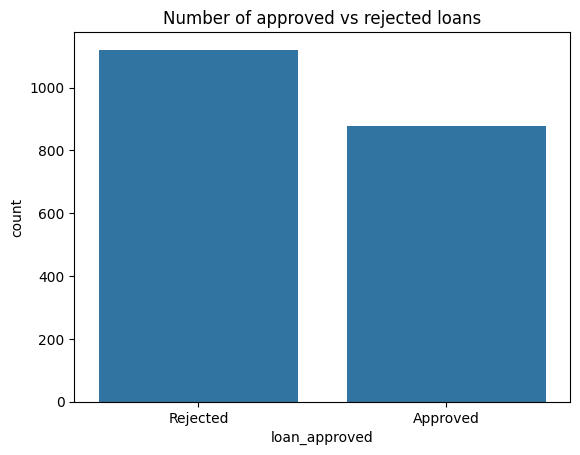

In [95]:
sns.countplot(data=df,x="loan_approved")
plt.title("Number of approved vs rejected loans")

<Axes: xlabel='loan_approved', ylabel='points'>

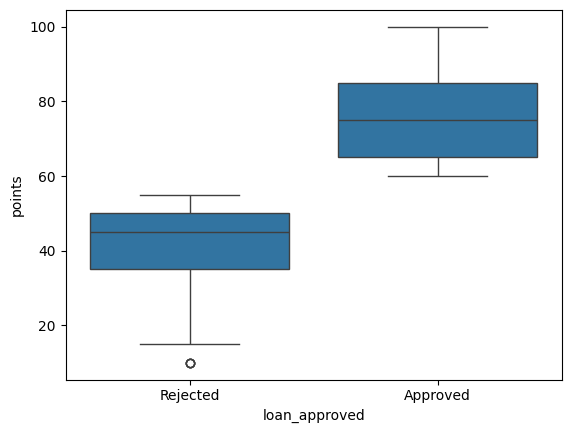

In [96]:
sns.boxplot(x='loan_approved',y='points',data=df)

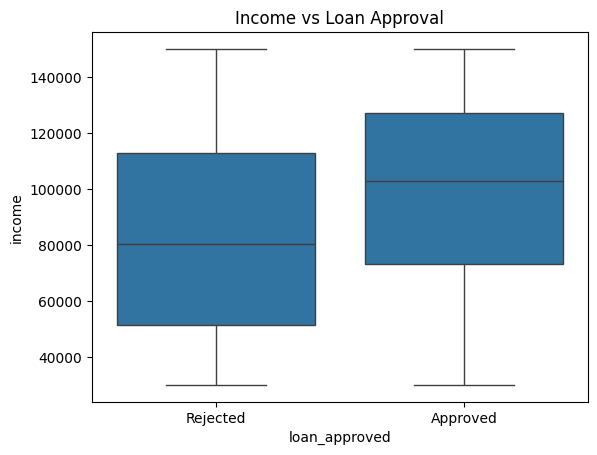

In [97]:
sns.boxplot(x='loan_approved',y='income',data=df)
plt.title("Income vs Loan Approval")
plt.show()


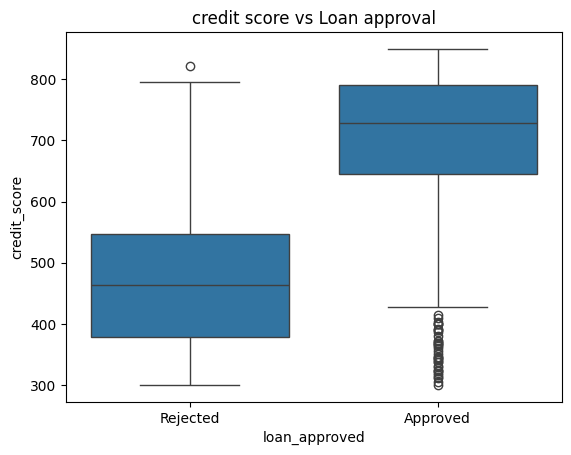

In [98]:
sns.boxplot(x='loan_approved',y='credit_score',data=df)
plt.title("credit score vs Loan approval")
plt.show()

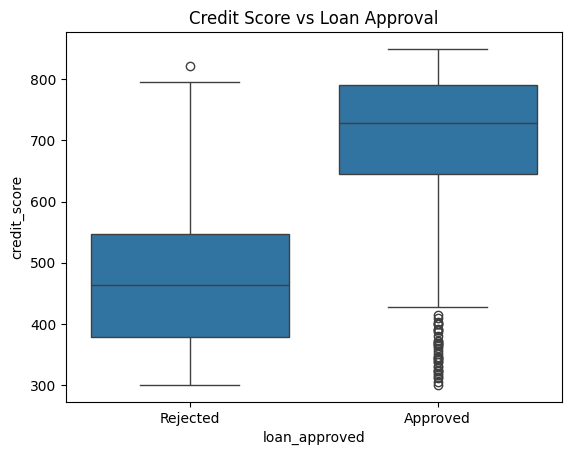

In [99]:
sns.boxplot(x='loan_approved',y="credit_score",data=df)
plt.title("Credit Score vs Loan Approval")
plt.show()

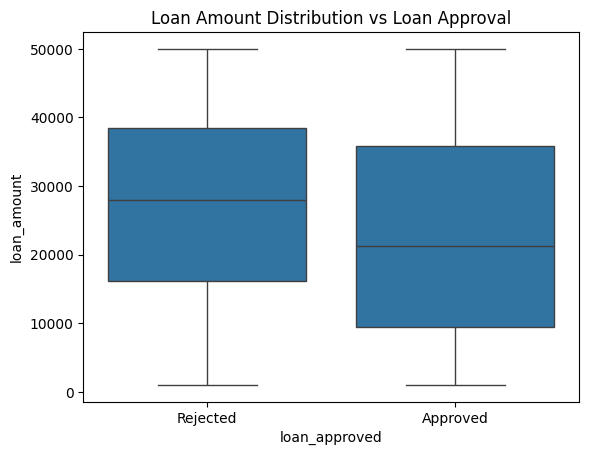

In [100]:
sns.boxplot(x='loan_approved', y='loan_amount', data=df)
plt.title('Loan Amount Distribution vs Loan Approval')
plt.show()

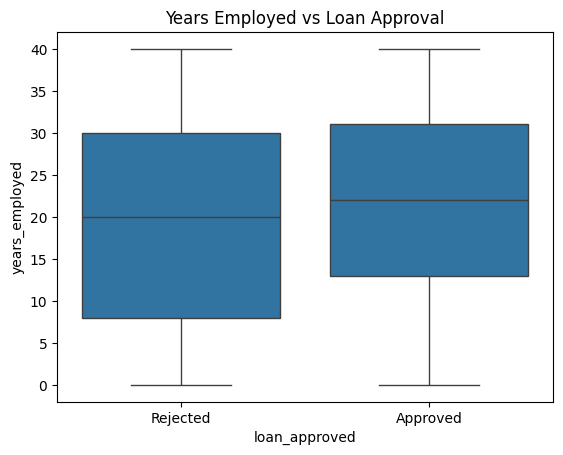

In [101]:
sns.boxplot(x='loan_approved', y='years_employed', data=df)
plt.title('Years Employed vs Loan Approval')
plt.show()


In [102]:
df['loan_approved'] = df['loan_approved'].map({
    'Rejected': 0,
    'Approved': 1
})


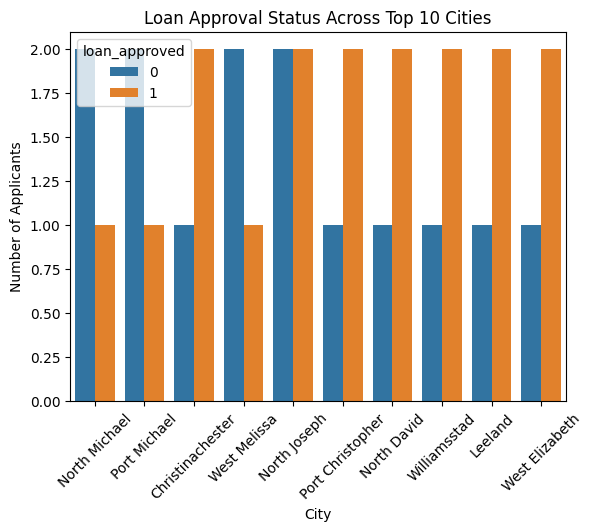

In [103]:
top_cities = df['city'].value_counts().head(10).index

sns.countplot(
    data=df[df['city'].isin(top_cities)],
    x='city',
    hue='loan_approved'
)

plt.title("Loan Approval Status Across Top 10 Cities")
plt.xlabel("City")
plt.ylabel("Number of Applicants")

plt.xticks(rotation=45)

plt.show()


Text(0.5, 1.0, 'Income vs Credit Score by Loan Approval Status')

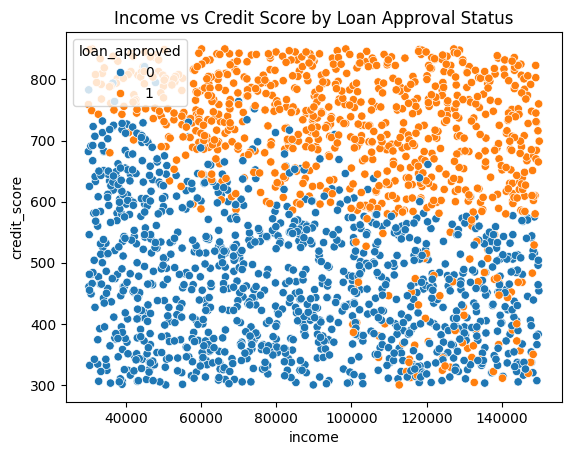

In [104]:
sns.scatterplot(
    x='income',
    y='credit_score',
    hue='loan_approved',
    data=df
)
plt.title("Income vs Credit Score by Loan Approval Status")

<Axes: xlabel='income', ylabel='loan_amount'>

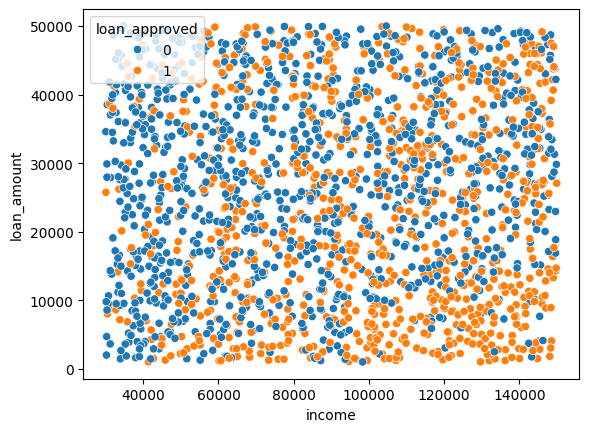

In [105]:
sns.scatterplot(
    x='income',
    y='loan_amount',
    hue='loan_approved',
    data=df
)

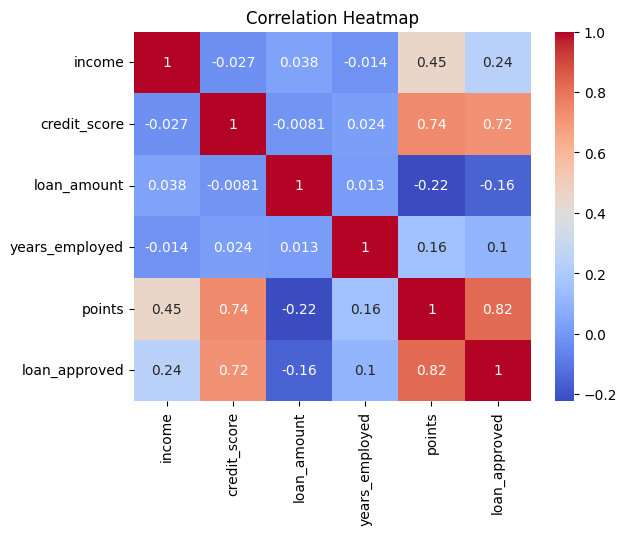

In [106]:
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [107]:
df['name'].unique()

<StringArray>
[        'Allison Hill',         'Brandon Hall',         'Rhonda Smith',
      'Gabrielle Davis',         'Valerie Gray',       'Darren Roberts',
           'Holly Wood',      'Nicholas Martin',          'Patty Perez',
           'Emily Rios',
 ...
       'Rebecca Newman', 'Christopher Morrison',        'Sierra Gentry',
        'Hannah Carter',          'Ryan Thomas',       'James Schaefer',
            'Diana Lin',        'Brandon Meyer',          'Jason Price',
         'Nicole Brown']
Length: 2000, dtype: str

In [108]:
df['name'] = pd.factorize(df['name'])[0]

In [109]:
df['city'].unique()

<StringArray>
[       'East Jill',    'New Jamesside',     'Lake Roberto',
 'West Melanieview',        'Mariastad',  'Port Jesseville',
      'Lake Joseph',       'Nelsonside',  'Port Leslieview',
   'Wilkersonmouth',
 ...
    'South Kenneth',        'Cookshire',     'Jenniferstad',
          'Basston',        'Tylertown',        'Robertton',
        'New Frank',       'East Haley',         'Adamland',
   'New Nathantown']
Length: 1882, dtype: str

In [110]:
df['city'] = pd.factorize(df['city'])[0]

In [111]:
df['loan_approved'].unique()

array([0, 1])

In [112]:
loan_approved_dict = {0 : 1 , 1 : 2}
df['loan_approved'] = df['loan_approved'].map(loan_approved_dict)

In [113]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            2000 non-null   int64  
 1   city            2000 non-null   int64  
 2   income          2000 non-null   int64  
 3   credit_score    2000 non-null   int64  
 4   loan_amount     2000 non-null   int64  
 5   years_employed  2000 non-null   int64  
 6   points          2000 non-null   float64
 7   loan_approved   2000 non-null   int64  
dtypes: float64(1), int64(7)
memory usage: 125.1 KB


In [114]:
x = df['loan_approved']

In [115]:
x

0       1
1       1
2       1
3       1
4       1
       ..
1995    2
1996    1
1997    2
1998    1
1999    1
Name: loan_approved, Length: 2000, dtype: int64

In [116]:
y = df.drop(['loan_approved'],axis = 1)

In [117]:
y

,name,city,income,credit_score,loan_amount,years_employed,points
0,0,0,113810,389,39698,27,50.0
1,1,1,44592,729,15446,28,55.0
2,2,2,33278,584,11189,13,45.0
3,3,3,127196,344,48823,29,50.0
4,4,4,66048,496,47174,4,25.0
...,...,...,...,...,...,...,...
1995,1995,1877,92163,770,12251,13,85.0
1996,1996,1878,38799,635,48259,17,40.0
1997,1997,1879,41957,763,16752,5,60.0
1998,1998,1880,139022,360,24031,35,55.0


In [118]:
df.isna().sum()

name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64

In [119]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            2000 non-null   int64  
 1   city            2000 non-null   int64  
 2   income          2000 non-null   int64  
 3   credit_score    2000 non-null   int64  
 4   loan_amount     2000 non-null   int64  
 5   years_employed  2000 non-null   int64  
 6   points          2000 non-null   float64
 7   loan_approved   2000 non-null   int64  
dtypes: float64(1), int64(7)
memory usage: 125.1 KB


In [120]:
df.drop(["points","city"],axis=1,inplace = True)

In [121]:
df

,name,income,credit_score,loan_amount,years_employed,loan_approved
0,0,113810,389,39698,27,1
1,1,44592,729,15446,28,1
2,2,33278,584,11189,13,1
3,3,127196,344,48823,29,1
4,4,66048,496,47174,4,1
...,...,...,...,...,...,...
1995,1995,92163,770,12251,13,2
1996,1996,38799,635,48259,17,1
1997,1997,41957,763,16752,5,2
1998,1998,139022,360,24031,35,1


In [122]:
df.drop(['name'],axis=1,inplace=True)

In [123]:
df.to_csv("clean_loan_data.csv")

In [124]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC , SVR


In [125]:
x = df.drop("loan_approved",axis=1)

In [126]:
y = df[['loan_approved']]

In [127]:
x

,income,credit_score,loan_amount,years_employed
0,113810,389,39698,27
1,44592,729,15446,28
2,33278,584,11189,13
3,127196,344,48823,29
4,66048,496,47174,4
...,...,...,...,...
1995,92163,770,12251,13
1996,38799,635,48259,17
1997,41957,763,16752,5
1998,139022,360,24031,35


In [128]:
y

,loan_approved
0,1
1,1
2,1
3,1
4,1
...,...
1995,2
1996,1
1997,2
1998,1


In [129]:
x_train , x_test ,  y_train , y_test = train_test_split(x , y , random_state = 42 , test_size = 0.2)

In [130]:
x_train

,income,credit_score,loan_amount,years_employed
968,49973,464,22397,24
240,70306,508,22644,5
819,88446,798,17896,21
692,70538,367,13343,29
420,96562,763,8472,6
...,...,...,...,...
1130,102140,495,48455,23
1294,107993,477,42635,0
860,83424,579,17117,20
1459,133247,392,13095,16


In [131]:
x_train.shape , y_train.shape , x_test.shape , y_test.shape

((1600, 4), (1600, 1), (400, 4), (400, 1))

In [132]:
sv = SVC()
sv.fit(x_train , y_train)

c:\Users\Pc\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [133]:
print(sv.score(x_train , y_train))
print(sv.score(x_test , y_test))

0.63
0.5975


In [134]:
from sklearn.tree import DecisionTreeClassifier , DecisionTreeRegressor
# dtc = DecisionTreeClassifier()
dtc = DecisionTreeClassifier(criterion='entropy')

In [135]:
dtc.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'entropy',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [136]:
dtc.fit(x_train,y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsam

In [137]:
print(dtc.score(x_train,y_train))
print(dtc.score(x_test,y_test))

1.0
0.9625


In [138]:
x_train

,income,credit_score,loan_amount,years_employed
968,49973,464,22397,24
240,70306,508,22644,5
819,88446,798,17896,21
692,70538,367,13343,29
420,96562,763,8472,6
...,...,...,...,...
1130,102140,495,48455,23
1294,107993,477,42635,0
860,83424,579,17117,20
1459,133247,392,13095,16


In [139]:
y_train

,loan_approved
968,1
240,1
819,2
692,1
420,2
...,...
1130,1
1294,1
860,1
1459,2


In [140]:
dtc.predict([[49973	, 464 , 22397 ,	24]])

c:\Users\Pc\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [141]:
x_test

,income,credit_score,loan_amount,years_employed
1860,130290,447,16496,10
353,54050,808,10217,21
1333,105529,698,32169,35
905,74057,648,6627,20
1289,39359,802,12388,30
...,...,...,...,...
965,139999,402,49121,24
1284,49528,584,47618,9
1739,124924,331,6481,20
261,64741,742,13172,37


In [142]:
dtc.predict([[130290 , 447 , 16496  ,10]])

c:\Users\Pc\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

Model Evaluation Techniques

Model evaluation techniques are used to measure how well a Machine Learning model performs on unseen data. For classification problems, a Confusion Matrix is commonly used to evaluate the model's predictions.

Actual ↓ / Predicted →	Positive	Negative
Positive	True Positive (TP)	False Negative (FN)
Negative	False Positive (FP)	True Negative (TN)
Common Evaluation Metrics

Accuracy = (TP + TN) / (TP + TN + FP + FN)
Precision = TP / (TP + FP)
Recall (Sensitivity) = TP / (TP + FN)
F1-Score = 2 × (Precision × Recall) / (Precision + Recall)

In [143]:
y_pred = dtc.predict(x_test)

In [144]:
from sklearn.metrics import classification_report , confusion_matrix 
confusion_matrix(y_test , y_pred)

array([[211,   6],
       [  9, 174]])

In [145]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test , y_pred)

0.9625

Model Evaluation Metrics

Machine Learning models are evaluated using different metrics to measure their performance on unseen data. Comparison of Evaluation Metrics

Metric	Best Used For	Key Advantage
ROC Curve & AUC (Area Under Curve)	Balanced datasets	Reflects overall model performance and is less affected by classification thresholds.
Precision-Recall (PR) Curve	Highly imbalanced datasets	Focuses on the positive class and is not influenced by a large number of True Negatives (TN).
AUC Score Interpretation

AUC Score	Performance Level
1.0	Perfect Model
0.90 – 0.99	Excellent
0.80 – 0.89	Good
0.70 – 0.79	Fair
0.50	Random Guessing
< 0.50	Worse than Random


In [146]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           1       0.96      0.97      0.97       217
           2       0.97      0.95      0.96       183

    accuracy                           0.96       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.96      0.96      0.96       400

